##### Training Decoder Network simulatanously with GAN.
| Experiment # | Question # | Model Type          | Remarks                | Key Parameters (e.g., Batch Size, Learning Rate) | Results (e.g., FID Score, Epochs) | Notes/Observations                              |
|--------------|------------|---------------------|------------------------------------------|-------------------------------------------------|----------------------------------|------------------------------------------------|
| 1        | Q8   Exp 1  |Decoder Network Trained with GAN (No discriminator noise)       |Loss function: Binary cross Entropy  | Batch Size: 64, Learning Rate: 0.0002            | - | Unstable training; all the images were blank with square patters of same colour.   |
| 2            | Q8   Exp 2  |Decoder Network Trained with GAN (Dis Input Noise=0.1)       |Loss function: Binary cross Entropy, Noise at Discriminator input: 0.1 | Batch Size: 64, Learning Rate: 0.0002            | FID: 250.21  18,281 iterations | Failed to generate good quality image (Reason found: Noise at Discriminator input was larger!)    |
| 3          | Q8            Exp 3  | Decoder Network Trained with GAN   (Dis Input Noise=0.05)        | Loss function: Binary cross Entropy, Noise at Discriminator input: 0.05 |  FID: 202, 18,281 iterations   |FID: 270.71  18,281 iterations    | Initially stable training but later found Mode Collapse after 12 epochs. |
| 4            | Q8  Exp 4   |Decoder Network Trained with GAN (Dis Input Noise=0.005)     | Loss function: Binary cross Entropy, Noise at Discriminator input: 0.005| Batch Size: 128, Learning Rate: 0.00005| FID: 180.21   18,281 iterations | Good results at this noise; images are still not as clear as they should be but are diverse and clearer, with no mode collapse.|


In [10]:
import os
import torch
import random
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.utils as vutils
from torchvision.utils import save_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)
# Set random seed for reproducibility
manualSeed = 999
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True)

Using device:  cuda


In [11]:
path = "data/augmented_animals"
image_height,image_width = 128,128
batch_size = 64
mean = torch.tensor([0.50869316, 0.50057036, 0.44047505])
std = torch.tensor([0.20191325, 0.19737212, 0.20100889])
transforms = transforms.Compose(
    [
        transforms.Resize((image_height, image_width)),
        transforms.CenterCrop((image_height, image_width)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)
train_data = datasets.ImageFolder(root=path, transform=transforms)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4)


##### Define Generator Decoder and Discriminator Networks

In [12]:
n_channels = 3  # RGB
z_latent = 100
fg = 256  # size of feature maps in generator
fd = 128  # size of feature maps in discriminator
n_epochs = 180 # number of epochs
beta1 = 0.5  
lr = 0.0002 
lambda_decoder = 1
# function to initialize weights for any object
def weights_init(c):
    class_name = c.__class__.__name__
    if class_name.find("Conv") != -1:
        nn.init.normal_(c.weight.data, 0.0, 0.02)
        # mean of Conv layer weights is taken 0.0
    elif class_name.find("BatchNorm") != -1:
        nn.init.normal_(c.weight.data, 0.0, 0.02)
        # mean of Batch Normalization layer weights is taken 0.0
        nn.init.constant_(c.bias.data, 0)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            self.block(z_latent, fg * 8, 4, 1, 0),
            self.block(fg * 8, fg * 4, 4, 2, 1),
            self.block(fg * 4, fg * 2, 4, 2, 1),
            self.block(fg * 2, fg, 4, 2, 1),
            self.block(fg , fg//2, 4, 2, 1),
            nn.ConvTranspose2d(fg//2, n_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def block(self, in_channels, out_channels, kernal_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels, out_channels, kernal_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True),
        )

    def forward(self, z):
        return self.main(z)


gen = Generator().to(device)
gen.apply(weights_init)
# print(gen)


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            self.block(n_channels, fd, 4, 2, 1),
            self.block(fd, fd * 2, 4, 2, 1),
            self.block(fd * 2, fd * 4, 4, 2, 1),
            self.block(fd * 4, fd * 8, 4, 2, 1),
            self.block(fd * 8, fd * 16, 4, 2, 1),
            nn.Conv2d(fd * 16, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def block(self, in_channels, out_channels, kernal_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernal_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        # Adding noise to the input images
        if self.training:  # Only add noise during training
            noise = torch.randn_like(x) * 0.005  # Adjust the noise scale as needed
            x = x + noise
        return self.main(x)


dis = Discriminator().to(device)
dis.apply(weights_init)
# print(dis)

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.main = nn.Sequential(
            self.block(n_channels, fd//2, 4, 2, 1),
            self.block(fd//2, fd, 4, 2, 1),
            self.block(fd, fd * 2, 4, 2, 1),
            self.block(fd * 2, fd * 4, 4, 2, 1),
            self.block(fd * 4, fd * 8, 4, 2, 1),
            nn.Conv2d(fd * 8, z_latent, 4, 1, 0, bias=False),
            )
    def block(self, in_channels, out_channels, kernal_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernal_size, stride, padding, bias=False
            ),
            nn.InstanceNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.main(x)


decode = Decoder().to(device)
decode.apply(weights_init)


def test():
    N, in_channels, H, W = 64, 3, 128, 128
    x = torch.randn((N, in_channels, H, W))  # 64,3,128,128
    disc = Discriminator()

    assert disc(x).shape == (N, 1, 1, 1), "Discriminator test failed"
    gen = Generator()
    z = torch.randn((N, z_latent, 1, 1))
    assert gen(z).shape == (N, in_channels, H, W), "Generator test failed"

    dec = Decoder()
    assert dec(x).shape == (N, 100, 1, 1), "Decoder test failed"
    print("All architectural tests passed")
test()

All architectural tests passed


In [13]:
# Training Cell
img_list = []
G_losses = []
D_losses = []
Reconstruction_losses = []
iters = 0
fixed_sample = torch.randn(64, z_latent, 1, 1, device=device)  # Ensure 64 images
criterion = nn.BCELoss()
reconstruction_criterion = nn.MSELoss()


# Optimizers
optimizer_gen = torch.optim.Adam(gen.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_dis = torch.optim.Adam(dis.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_dec = torch.optim.Adam(decode.parameters(), lr=lr, betas=(beta1, 0.999))



print("Training starts ...")
os.makedirs("final_decoder_output", exist_ok=True)
for epoch in range(n_epochs):
    for i, data in enumerate(train_loader, 0):
#############################################################
#       Training Discriminator                              #
#############################################################
        real_data = data[0].to(device)
        batch_size = real_data.size(0)
        discriminator_output_real = dis(real_data).view(-1)
        error_dis_real = criterion(discriminator_output_real, torch.full_like(discriminator_output_real, 0.9))
        # error_dis_real.backward()
        # Sampling from Normal Distribution
        sample = torch.randn(batch_size, z_latent, 1, 1, device=device)
        generator_output = gen(sample)
        discriminator_output_fake = dis(generator_output.detach()).view(-1)
        error_dis_fake = criterion(discriminator_output_fake, torch.full_like(discriminator_output_fake, 0.0))
        # error_dis_fake.backward()
        error_dis = (error_dis_real + error_dis_fake)/2
                
        dis.zero_grad()
        error_dis.backward()
        optimizer_dis.step()
#############################################################
#       Training Generator and Decoder together             #
#############################################################
        generator_output = gen(sample)
        discriminator_output = dis(generator_output)
        decoder_output = decode(generator_output)
        # GAN Loss to fool the discriminator
        error_gen = criterion(discriminator_output, torch.full_like(discriminator_output, 0.9))
        error_gen = error_gen * 0.1
        # Reconstruction Loss for Decoder
        decoder_loss = torch.norm(sample - decoder_output)
        # Total Generator+Decoder Loss
        decoder_loss = decoder_loss * 0.01 # To scale down the decoder loss
        total_gen_loss = error_gen + lambda_decoder * decoder_loss

        optimizer_gen.zero_grad()
        optimizer_dec.zero_grad()
        total_gen_loss.backward() # Backpropagation for Generator and Decoder
        optimizer_gen.step()
        optimizer_dec.step()

        # Generator and Discriminator Losses
        G_losses.append(total_gen_loss.item())
        D_losses.append(error_dis.item())
        Reconstruction_losses.append(decoder_loss.item())

        # Output training stats
        if i % 100 == 0:
            print(
                f"Epoch [{epoch}/{n_epochs}] Batch {i}/{len(train_loader)} Loss D: {error_dis:.4f}, loss G: {error_gen:.4f}, Reconstruction loss: {decoder_loss:.4f}"
            )

        if (iters % 100 == 0) or (
            (epoch == n_epochs - 1) and (i == len(train_loader) - 1)
        ):
            fake = gen(fixed_sample).detach().cpu()
            img_list.append(vutils.make_grid(fake, nrow=8, padding=2, normalize=True))
            save_image(fake, f"final_decoder_output/fake_samples_epoch_{epoch}_iter_{i}.png", nrow=8, normalize=True)
        iters += 1


print("Training ends ...")

Training starts ...
Epoch [0/180] Batch 0/254 Loss D: 0.6926, loss G: 0.0874, Reconstruction loss: 1.7669
Epoch [0/180] Batch 100/254 Loss D: 0.1656, loss G: 0.5719, Reconstruction loss: 0.6884
Epoch [0/180] Batch 200/254 Loss D: 0.1728, loss G: 0.5190, Reconstruction loss: 0.5080
Epoch [1/180] Batch 0/254 Loss D: 0.2321, loss G: 0.4122, Reconstruction loss: 0.4764
Epoch [1/180] Batch 100/254 Loss D: 0.2983, loss G: 0.5928, Reconstruction loss: 0.4164
Epoch [1/180] Batch 200/254 Loss D: 0.1791, loss G: 0.4768, Reconstruction loss: 0.4585
Epoch [2/180] Batch 0/254 Loss D: 0.2048, loss G: 0.4310, Reconstruction loss: 0.3924
Epoch [2/180] Batch 100/254 Loss D: 0.2608, loss G: 0.4261, Reconstruction loss: 0.3955
Epoch [2/180] Batch 200/254 Loss D: 0.2476, loss G: 0.5252, Reconstruction loss: 0.4314
Epoch [3/180] Batch 0/254 Loss D: 1.2350, loss G: 0.5843, Reconstruction loss: 0.3404
Epoch [3/180] Batch 100/254 Loss D: 0.2640, loss G: 0.4891, Reconstruction loss: 0.3466
Epoch [3/180] Batch 

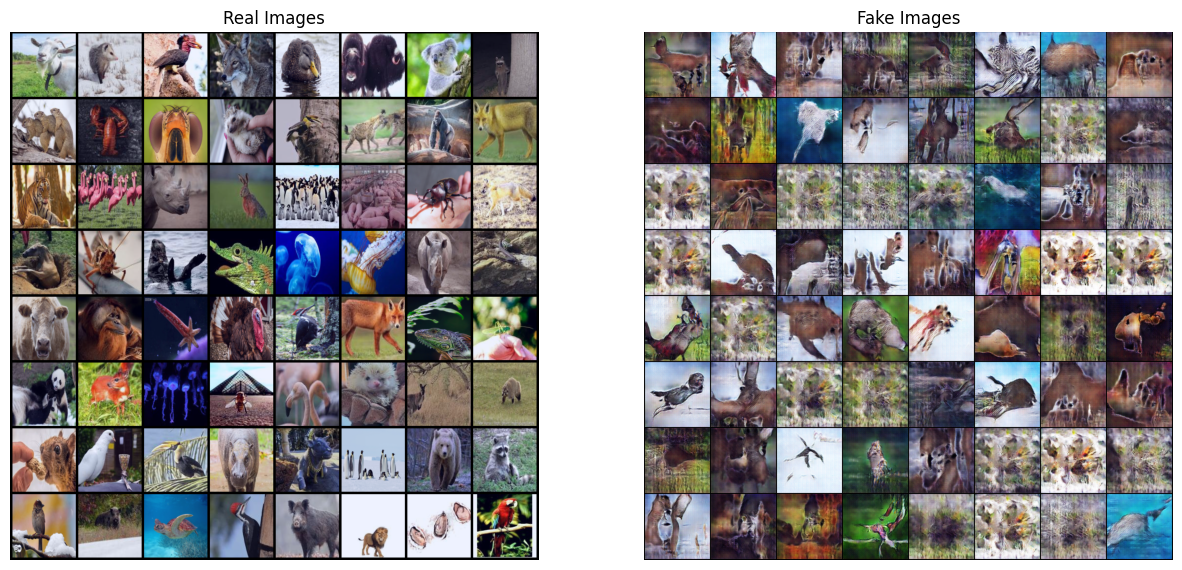

In [20]:
torch.save(decode, 'decoder.pth')
# Plot Real and Fake Images
real_batch = next(iter(train_loader))
plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real Images")

plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(), (1, 2, 0)
    )
)

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(
    np.transpose(img_list[-194], (1, 2, 0))
)
plt.show()

### Generate Decoder Output vector for using it in Question 9.

In [15]:
# Generated Decoder Output Vector for next question
import csv
model = torch.load('decoder_100_epoch.pth') # decoder model
model.eval()
f = open('latent_data.csv', 'w',newline='')
writer = csv.writer(f)
row = []
count = 0
path_original = "data/animals"    

original_data_loader = DataLoader(datasets.ImageFolder(root=path_original, transform=transforms), batch_size=64, shuffle=False, num_workers=4)
for images, labels in original_data_loader:
    images = images.to(device)
    count += 1
    with torch.no_grad():
        z = model(images)
        z = z.view(z.size(0), -1).cpu().numpy()
        labels = labels.cpu().numpy().reshape(-1,1)
        data = np.hstack((labels, z))
        writer.writerows(data)
print(count)
f.close()



C:\Users\Shivam\AppData\Local\Temp\ipykernel_28156\252041306.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('decoder_100_epoch.pth') # decoder model


85


### Observation/Learning/Interpretation:
- Stable GAN architecture become unstable after addition of decoder network.
- We Tried hard to change many hyperparameters to get stable training.
- Finally these two modification gave us final result as above.
    1) Generator features > Decoder and Discriminator features- This make Generator more complex than other two.
    - Complex Generator is capable to identify features of images better.
    - Small Decoder may be less capable to generate output vectors.
    2) Scale Down the Loss if order of noise is different.
    - Decoder's actual loss was in order of tens (e.g. 57.6,61.2,43.3...)
    - Scaling it down to 0.01 take all the losses in same order which helps learn better. (e.g. 0.576,0.612,0.433...)
    3) Adding small noise to Discriminator.
    - Therom in "Principled method for GAN training" Paper Suggests us that by adding small noise to discriminator makes the function continuous. We added noise of 0.1 but disappointed by seeing results. After many experiment we found that 0.005 is more proper scale of noise that gave us stable results.